In [1]:
import numpy as np
import soundfile as sf
import scipy.signal as signal
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import os

# Pregunta 1

Se crean funciones para cargar audio y generar ruido.

In [36]:
# ============================================================
# FUNCIONES BÁSICAS DE CARGA Y GENERACIÓN
# ============================================================

def load_audio(filename, fs_target=None):
    s, fs = sf.read(filename)
    if s.ndim > 1:
        s = np.mean(s, axis=1)
    if fs_target and fs != fs_target:
        num = int(len(s) * fs_target / fs)
        s = signal.resample(s, num)
        fs = fs_target
    return s, fs

def generate_noise(noise_type, length, fs, seed=None):
    if seed is not None:
        np.random.seed(seed)
    t = np.arange(length) / fs
    if noise_type == 'sin':
        freq = np.random.choice([200, 400])
        v = np.sin(2 * np.pi * freq * t)
    elif noise_type == 'colored':
        white = np.random.randn(length)
        b, a = signal.butter(4, [300 / (fs / 2), 1500 / (fs / 2)], btype='band')
        v = signal.lfilter(b, a, white)
    else:
        raise ValueError("Tipo de ruido no reconocido. Use 'sin' o 'colored'.")
    return v

## 1.a

Se carga un archivo corto de unos 5 segundos

In [37]:
# ============================================================
# SIMULACIÓN
# ============================================================

audio_file = '1282518320398209217.wav'
fs_target = 16000

# Cargar señal de voz
s, fs = load_audio(audio_file, fs_target)

## 1.b

Se crean los dos tipos de ruido

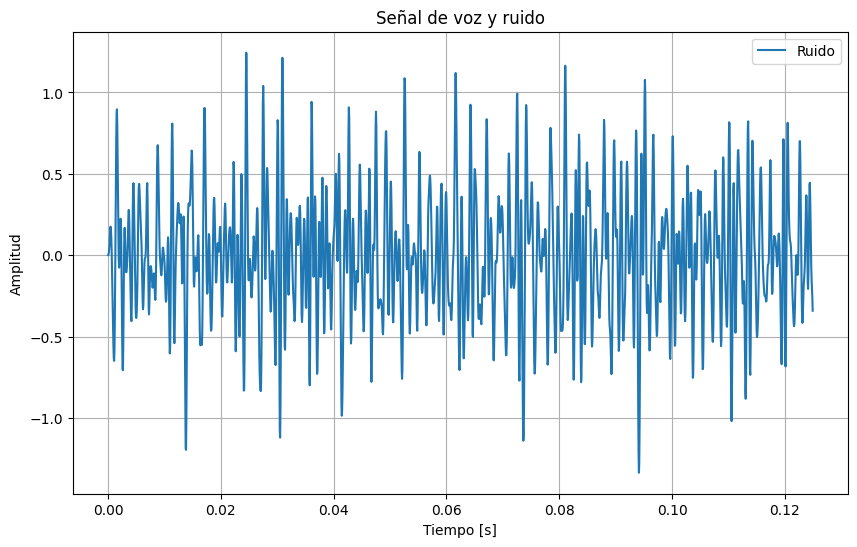

In [38]:
noise_type = 'colored'
seed = 42
# Generar ruido y referencia
v = generate_noise(noise_type, len(s), fs, seed)

# Graficar ruido y señal contaminada
t_axis = np.arange(len(s)) / fs

plt.figure(figsize=(10, 6))
plt.plot(t_axis[0:2000], v[0:2000], label='Ruido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal de voz y ruido')
plt.legend()
plt.grid(True)
plt.show()

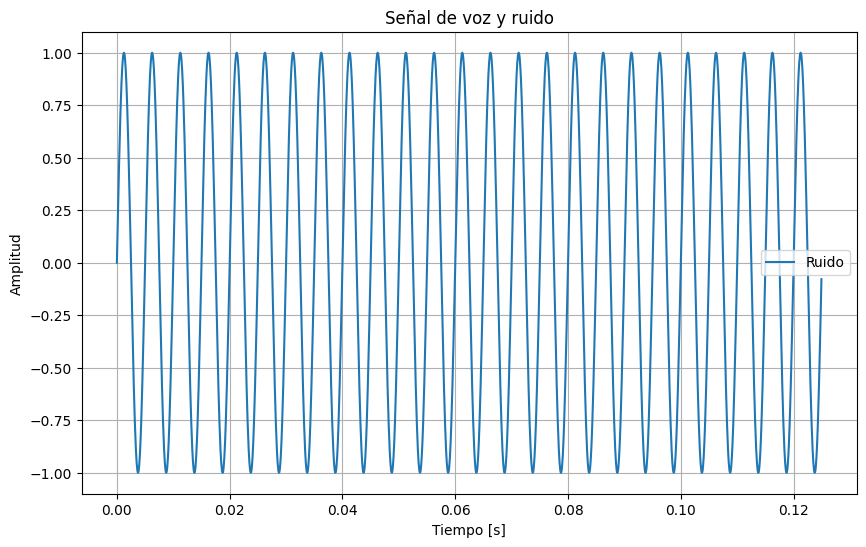

In [39]:
noise_type = 'sin'
# Generar ruido y referencia
v = generate_noise(noise_type, len(s), fs, seed)

# Graficar ruido y señal contaminada
t_axis = np.arange(len(s)) / fs

plt.figure(figsize=(10, 6))
plt.plot(t_axis[0:2000], v[0:2000], label='Ruido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal de voz y ruido')
plt.legend()
plt.grid(True)
plt.show()


## 1.c

Se forma la señal contaminada y se reproduce

In [40]:
d = s + v

display(Audio(d, rate=fs))

## 1.d

Se define la señal de referencia de ruido

In [41]:
def create_reference_noise(v, seed=None):
    if seed is not None:
        np.random.seed(seed)
    w = 0.05 * np.random.randn(len(v))
    g = v + 0.5 * np.concatenate(([0], v[:-1])) + w
    return g

g = create_reference_noise(v, seed)

# Pregunta 2

## 2.a

Se define una función para aplicar el algoritmo LMS

In [42]:
def lms_filter(d, g, M, mu):
    N = len(d)
    h = np.zeros(M)
    v_hat = np.zeros(N)
    e = np.zeros(N)
    h_hist = np.zeros((N, M))

    for n in range(M, N):
        g_vec = g[n:n-M:-1]
        v_hat[n] = np.dot(h, g_vec)
        e[n] = d[n] - v_hat[n]
        h = h + mu * e[n] * g_vec
        h_hist[n, :] = h

    return e, v_hat, h_hist

## 2.b

Se configura el filtro con diferentes parámetros.

In [43]:
M1 = 32
mu1 = 0.001
e1, v_hat1, h_hist1 = lms_filter(d, g, M1, mu1)
display(Audio(e1, rate=fs))

M2 = 64
mu2 = 0.001
e2, v_hat2, h_hist2 = lms_filter(d, g, M2, mu2)
display(Audio(e2, rate=fs))

M3 = 128
mu3 = 0.001
e3, v_hat3, h_hist3 = lms_filter(d, g, M3, mu3)
display(Audio(e3, rate=fs))

## 2.c

Se calcula la potencia y el SNR antes y despues del filtro

In [44]:
# ============================================================
# FUNCIONES DE ANÁLISIS Y FILTRADO
# ============================================================

def compute_power(x):
    return np.mean(x**2)

def compute_snr(clean, noisy):
    power_signal = compute_power(clean)
    power_noise = compute_power(noisy - clean)
    return 10 * np.log10(power_signal / power_noise)

snr_in = compute_snr(s, d)
print(f'SNR de entrada: {snr_in:.2f} dB')
snr_out1 = compute_snr(s, e1)
print(f'SNR de salida (M={M1}, mu={mu1}): {snr_out1:.2f} dB')
snr_out2 = compute_snr(s, e2)
print(f'SNR de salida (M={M2}, mu={mu2}): {snr_out2:.2f} dB')
snr_out3 = compute_snr(s, e3)
print(f'SNR de salida (M={M3}, mu={mu3}): {snr_out3:.2f} dB')

SNR de entrada: -23.52 dB
SNR de salida (M=32, mu=0.001): 6.55 dB
SNR de salida (M=64, mu=0.001): 6.57 dB
SNR de salida (M=128, mu=0.001): 4.94 dB


## 2.d

Error entre el audio original y el filtrado

SNR antes del filtro: -23.52 dB
SNR después del filtro: 6.57 dB
Mejora: 30.08 dB


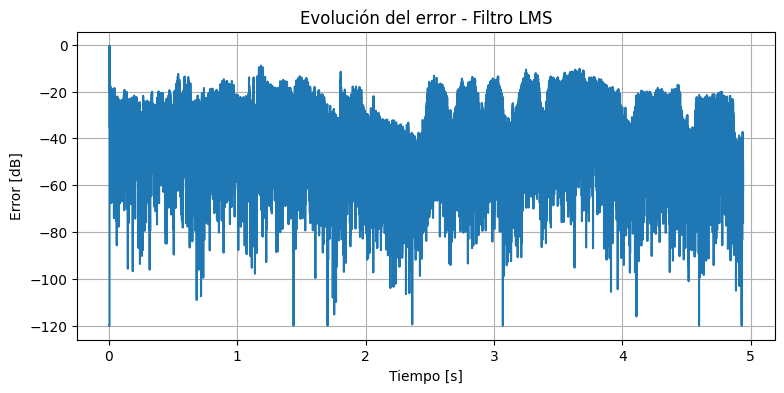

In [45]:
# ============================================================
# APLICAR FILTRO LMS Y EVALUACIÓN
# ============================================================

e, v_hat, h_hist = lms_filter(d, g, M, mu)

snr_in = compute_snr(s, d)
snr_out = compute_snr(s, e)

print(f"SNR antes del filtro: {snr_in:.2f} dB")
print(f"SNR después del filtro: {snr_out:.2f} dB")
print(f"Mejora: {snr_out - snr_in:.2f} dB")

# Gráfico del error
e_db = 10 * np.log10(np.maximum(e**2, 1e-12))
plt.figure(figsize=(9, 4))
plt.plot(t_axis, e_db, label="Error (dB)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error [dB]")
plt.title("Evolución del error - Filtro LMS")
plt.grid(True)
plt.show()

## 2.e

Audios antes y después del filtro

In [46]:
display(Audio(s, rate=fs))
display(Audio(d, rate=fs))
display(Audio(e1, rate=fs))
display(Audio(e2, rate=fs))
display(Audio(e3, rate=fs))

El ruido mejora bastante comparado con el ruido mejorado. Mientras major el orden del filtro, el ruido se ve un poco más atenuado.

# Pregunta 3

Se cambia el ruido a mitad del audio

In [47]:
# --- Generar ruido cambiante ---
N = len(s)
half = N // 2
t1 = np.arange(half) / fs
t2 = np.arange(N - half) / fs

np.random.seed(seed)
if noise_type == 'sin':
    # Primer ruido: 200 Hz, segundo: 400 Hz
    v1 = np.sin(2 * np.pi * 200 * t1)
    v2 = 0.8 * np.sin(2 * np.pi * 400 * t2)
elif noise_type == 'colored':
    # Primer ruido: pasabanda 300–1500 Hz
    white1 = np.random.randn(half)
    b1, a1 = signal.butter(4, [300 / (fs / 2), 1500 / (fs / 2)], btype='band')
    v1 = signal.lfilter(b1, a1, white1)
    # Segundo ruido: pasabanda 2000–4000 Hz
    white2 = np.random.randn(N - half)
    b2, a2 = signal.butter(4, [2000 / (fs / 2), 4000 / (fs / 2)], btype='band')
    v2 = signal.lfilter(b2, a2, white2)
else:
    raise ValueError("Tipo de ruido no reconocido. Use 'sin' o 'colored'.")

v = np.concatenate((v1, v2))

# --- Señal contaminada ---
d = s + v

# --- Filtro LMS ---

M = 64
mu = 0.001
g = create_reference_noise(v, seed)
e, v_hat, h_hist = lms_filter(d, g, M, mu)

# --- Mostrar audios ---
display(Audio(s, rate=fs))      # Audio original
display(Audio(v, rate=fs))      # Solo ruido cambiante
display(Audio(d, rate=fs))      # Audio contaminado
display(Audio(e, rate=fs))      # Audio filtrado